## Kernel to load: vax_inc_general 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import pycountry
import pickle
from matplotlib import rcParams
import re
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter, FixedLocator, PercentFormatter
from matplotlib.lines import Line2D
from scipy.interpolate import make_interp_spline
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch 
import json

In [2]:
notebook_dir = os.path.dirname(os.getcwd())
source_data_path=os.path.join(notebook_dir, "Common Source Data")
sys.path.append(source_data_path)
from country_codes import countries

In [3]:
df_vaccine=pd.read_csv(os.path.join(notebook_dir,'Vaccination Coverage','Supplementary Spreadsheet- Vaccination Coverage Estimates.csv'))
df_incidence=pd.read_csv('Supplementary Spreadsheet- Incidence Estimates.csv')

In [4]:
df=df_vaccine.merge(df_incidence.drop(columns=['Country']),on=['ISO3','Year','Animal','Disease'],how='outer')
df=df[df['Year']>=2005] # Vacc coverage before 2005 causes some countries to have 0 estimated incidence at odd past years due to group sum function

In [5]:
pop_countries_cattle = df['ISO3']

countries = {}
for country in pycountry.countries:
    countries[country.alpha_3] = country.name
    
for row in df.iterrows():
    if (row[1]['Country']==row[1]['Country']):
        countries[row[1]['ISO3']]=row[1]['Country']

codes_pop_cattle = [countries.get(country, 'Unknown code:'+country) for country in pop_countries_cattle]

iso3s_pop_cattle=[]

for i in pop_countries_cattle:
    try:
        iso3s_pop_cattle+=[countries[i]]
    except:
        iso3s_pop_cattle+=[None]
        
df['Country']=iso3s_pop_cattle


print(np.unique(codes_pop_cattle)) 

['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola' 'Argentina'
 'Armenia' 'Aruba' 'Australia' 'Austria' 'Azerbaijan' 'Bahrain'
 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bhutan'
 'Bolivia, Plurinational State of' 'Bosnia and Herzegovina' 'Botswana'
 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi'
 'Cambodia' 'Cameroon' 'Canada' 'Cape Verde' 'Cayman Islands'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo' 'Congo, The Democratic Republic of the' 'Cook Islands'
 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia' "Côte d'Ivoire"
 'Denmark' 'Djibouti' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Falkland Islands (Malvinas)' 'Faroe Islands' 'Fiji' 'Finland' 'France'
 'French Guiana' 'French Polynesia' 'Gabon' 'Gambia' 'Georgia' 'Germany'
 'Ghana' 'Greece' 'Greenland' 'Grenada' 'Guadeloupe' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Guyana' 'Haiti' 'Hondu

In [6]:
who_regions = {
    "African Region (AFR)": [
        "Angola", "Central African Republic", "Congo", "Democratic Republic of the Congo",
        "Equatorial Guinea", "Gabon",
        "Burundi", "Comoros", "Eritrea", "Ethiopia", "Kenya", "Madagascar", "Malawi",
        "Mozambique", "Rwanda", "South Sudan", "Uganda", "United Republic of Tanzania",
        "Zambia", "Réunion",
        "Botswana", "Eswatini", "Lesotho", "Namibia", "South Africa", "Zimbabwe",
        "Benin", "Burkina Faso", "Cabo Verde", "Cameroon", "Chad", "Côte d'Ivoire",
        "Gambia", "Ghana", "Guinea", "Guinea-Bissau", "Liberia", "Mali", "Mauritania",
        "Niger", "Nigeria", "Sao Tome and Principe", "Senegal", "Sierra Leone", "Togo",
        "Mauritius", "Seychelles"
    ],
    "Region of the Americas (AMR)": [
        "Bolivia", "Ecuador", "Peru",
        "Colombia", "Costa Rica", "El Salvador", "Guatemala", "Honduras", "Mexico",
        "Nicaragua", "Panama", "Venezuela",
        "Argentina", "Chile", "Uruguay",
        "Brazil", "Paraguay", "French Guiana",
        "Antigua and Barbuda", "Bahamas", "Barbados", "Belize", "Cuba", "Dominica",
        "Dominican Republic", "Grenada", "Guyana", "Haiti", "Jamaica",
        "Saint Kitts and Nevis", "Saint Lucia", "Saint Vincent and the Grenadines",
        "Suriname", "Trinidad and Tobago", "Aruba", "Curaçao", "Saint Martin (French part)",
        "Sint Maarten (Dutch part)", "Turks and Caicos Islands", "Virgin Islands, British",
        "Virgin Islands, U.S.", "Martinique", "Guadeloupe",
        "Canada", "United States of America", "Bermuda", "Puerto Rico", "Cayman Islands"
    ],
    "Eastern Mediterranean Region (EMR)": [
        "Afghanistan", "Algeria", "Bahrain", "Egypt", "Iran", "Iraq", "Jordan",
        "Kuwait", "Lebanon", "Libya", "Morocco", "Oman", "Palestine", "Qatar",
        "Saudi Arabia", "Sudan", "Syrian Arab Republic", "Tunisia",
        "United Arab Emirates", "Yemen",
        "Djibouti", "Somalia",
        "Pakistan"
    ],
    "European Region (EUR)": [
        "Albania", "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
        "Hungary", "Kosovo", "Montenegro", "North Macedonia", "Poland", "Romania",
        "Serbia", "Serbia and Montenegro", "Slovakia", "Slovenia",
        "Belarus", "Estonia", "Latvia", "Lithuania", "Republic of Moldova",
        "Russian Federation", "Ukraine",
        "Andorra", "Austria", "Belgium", "Cyprus", "Denmark", "Finland", "France",
        "Germany", "Greece", "Guernsey", "Iceland", "Ireland", "Isle of Man",
        "Italy", "Jersey", "Liechtenstein", "Luxembourg", "Malta", "Monaco",
        "Netherlands", "Norway", "Portugal", "San Marino", "Spain", "Sweden",
        "Switzerland", "United Kingdom", "Gibraltar", "Faroe Islands",
        "Armenia", "Azerbaijan", "Georgia", "Kazakhstan", "Kyrgyzstan",
        "Tajikistan", "Turkmenistan", "Uzbekistan",
        "Israel", "Türkiye",
        "Greenland"
    ],
    "South-East Asia Region (SEAR)": [
        "Bangladesh", "Bhutan", "India", "Nepal",
        "Indonesia", "Myanmar", "Thailand", "Timor-Leste", "Sri Lanka",
        "Maldives"
    ],
    "Western Pacific Region (WPR)": [
        "China", "Democratic People's Republic of Korea", "Taiwan", "Hong Kong", "Macao",
        "Brunei Darussalam", "Japan", "Republic of Korea", "Singapore",
        "Australia", "New Zealand", "American Samoa", "Cook Islands", "Tokelau",
        "Fiji", "Kiribati", "Marshall Islands", "Micronesia", "Nauru", "Niue",
        "Palau", "Papua New Guinea", "Samoa", "Solomon Islands", "Tonga",
        "Tuvalu", "Vanuatu", "New Caledonia", "French Polynesia",
        "Cambodia", "Malaysia", "Philippines", "Viet Nam", "Lao People's Democratic Republic",
        "Guam", "Northern Mariana Islands"
    ]
}
data = []
for region, countries in who_regions.items():
    for country in countries:
        data.append({"Country": country, "Region": region})

# Convert the list into a pandas DataFrame
df_country_regions = pd.DataFrame(data)

In [7]:
income_df=pd.read_csv(os.path.join(source_data_path,'World Bank data','Income_level_by_country.csv'))
# First, create a mapping from ISO3 to 2025 Income level
income_2025 = income_df[income_df['Year'] == 2025][['ISO3', 'Income level']]
iso3_to_2025_income = dict(zip(income_2025['ISO3'], income_2025['Income level']))

# Then update pre-2025 income levels based on this mapping
mask = income_df['Year'] < 2024
income_df.loc[mask, 'Income level'] = income_df.loc[mask, 'ISO3'].map(iso3_to_2025_income)
income_df['Income level'] = income_df['Income level'].replace({
    'Low-income countries': 'Low income',
    'Lower-middle-income countries': 'Lower middle income',
    'Upper-middle-income countries': 'Upper middle income',
    'High-income countries': 'High income'
})

# Sort by Year so latest is last
income_latest = (
    income_df.sort_values(["ISO3", "Year"])
             .groupby("ISO3", as_index=False)
             .last()[["ISO3", "Income level"]]
)


In [8]:
df_pop_cattle=pd.read_csv(os.path.join(source_data_path,'Processed data','FAO Populations','cattle_pop.csv'))
df_pop_cattle = df_pop_cattle.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last').loc[:,['Area','Value','ISO3','Year']]
df_pop_cattle=df_pop_cattle.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_cattle['Animal']=['Cattle']*df_pop_cattle.shape[0]
df_pop_cattle.rename(columns={'Value':'latest pop'},inplace=True)


df_pop_poultry=pd.read_csv(os.path.join(source_data_path,'Processed data','FAO Populations','poultry_pop.csv'))
df_pop_poultry = df_pop_poultry.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last')
df_pop_poultry = (
    df_pop_poultry.groupby(['ISO3', 'Year Code'], as_index=False)
    .agg({
        'Domain Code': 'first',
        'Domain': 'first',
        'Area Code (M49)': 'first',
        'Area': 'first',
        'Element Code': 'first',
        'Element': 'first',
        'Item Code (CPC)': 'first',
        'Year Code': 'first',
        'Year': 'first',
        'Unit': 'first',
        'Value': 'sum',  
        'Flag': 'first',
        'Flag Description': 'first',
        'Note': 'first',
        'ISO3':'first'
    })
)
df_pop_poultry['Item'] = 'Poultry'
df_pop_poultry=df_pop_poultry.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_poultry.rename(columns={'Value':'latest pop'},inplace=True)
df_pop_poultry['Animal']=['Poultry']*df_pop_poultry.shape[0]
df_pop_poultry['latest pop']*=1000

df_pop_swine=pd.read_csv(os.path.join(source_data_path,'Processed data','FAO Populations','swine_pop.csv'))
df_pop_swine = df_pop_swine.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last')
df_pop_swine=df_pop_swine.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_swine.rename(columns={'Value':'latest pop'},inplace=True)
df_pop_swine['Animal']=['Pigs']*df_pop_swine.shape[0]


df_pop_killed_cattle=pd.read_csv(os.path.join(source_data_path,'Processed data','FAO Populations','killed_cattle_pop.csv'))
df_pop_killed_cattle = df_pop_killed_cattle.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last')
df_pop_killed_cattle.rename(columns={'Value':'latest pop'},inplace=True)
df_pop_killed_cattle=df_pop_killed_cattle.sort_values('Year').loc[:,['Area','latest pop','ISO3','Year']]
df_pop_killed_cattle['Animal']=['Cattle']*df_pop_killed_cattle.shape[0]

df_pop_killed_poultry=pd.read_csv(os.path.join(source_data_path,'Processed data','FAO Populations','killed_poultry_pop.csv'))
df_pop_killed_poultry = df_pop_killed_poultry.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last')
df_pop_killed_poultry = (
    df_pop_killed_poultry.groupby(['ISO3', 'Year Code'], as_index=False)
    .agg({
        'Domain Code': 'first',
        'Domain': 'first',
        'Area Code (M49)': 'first',
        'Area': 'first',
        'Element Code': 'first',
        'Element': 'first',
        'Item Code (CPC)': 'first',
        'Year Code': 'first',
        'Year': 'first',
        'Unit': 'first',
        'Value': 'sum', 
        'Flag': 'first',
        'Flag Description': 'first',
        'Note': 'first',
        'ISO3':'first'
    })
)
df_pop_killed_poultry['Item'] = 'Poultry'
df_pop_killed_poultry=df_pop_killed_poultry.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_killed_poultry.rename(columns={'Value':'latest pop'},inplace=True)
df_pop_killed_poultry['Animal']=['Poultry']*df_pop_killed_poultry.shape[0]
df_pop_killed_poultry['latest pop']*=1000

df_pop_killed_swine=pd.read_csv(os.path.join(source_data_path,'Processed data','FAO Populations','killed_swine_pop.csv'))
df_pop_killed_swine = df_pop_killed_swine.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last')
df_pop_killed_swine=df_pop_killed_swine.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_killed_swine.rename(columns={'Value':'latest pop'},inplace=True)
df_pop_killed_swine['Animal']=['Pigs']*df_pop_killed_swine.shape[0]

In [9]:
df_pops=pd.concat([df_pop_cattle,df_pop_poultry,df_pop_swine])

In [10]:
df_killed_pops=pd.concat([df_pop_killed_cattle,df_pop_killed_poultry,df_pop_killed_swine])
df_killed_pops.rename(columns={'latest pop':'killed pop'},inplace=True)

In [11]:
df_calculations_cases=df.merge(df_pops,how='left',on=['ISO3','Animal','Year'])
df_calculations_cases=df_calculations_cases.merge(df_killed_pops,how='left',on=['ISO3','Animal','Year'])

In [12]:
df_calculations_cases['Number of Vaccinated Lower']=df_calculations_cases['Vaccination Coverage (%) Lower']/100*df_calculations_cases['latest pop']
df_calculations_cases['Number of Vaccinated Upper']=df_calculations_cases['Vaccination Coverage (%) Upper']/100*df_calculations_cases['latest pop']
df_calculations_cases['Number of Vaccinated Estimate']=df_calculations_cases['Vaccination Coverage (%)']/100*df_calculations_cases['latest pop']

In [13]:
from country_codes import countries
return_country = {v: k for k, v in countries.items()}

In [14]:
country_regions_iso3=df_country_regions['Country']
codes_regions=[countries.get(country, 'Unknown code:'+country) for country in country_regions_iso3]

iso3s_regions=[]

for i in country_regions_iso3:
    try:
        iso3s_regions+=[countries[i]]
    except:
        iso3s_regions+=[None]

df_country_regions['ISO3']=iso3s_regions

In [15]:
df_country_regions['Region']=[i.split(' (')[0] for i in df_country_regions['Region']]

In [16]:
df_calculations_cases=df_calculations_cases.merge(df_country_regions,how='left',on=['ISO3'])

In [17]:
income_df=pd.read_csv(os.path.join(source_data_path,'World Bank data','Income_level_by_country.csv'))
# First, create a mapping from ISO3 to 2025 Income level
income_2025 = income_df[income_df['Year'] == 2025][['ISO3', 'Income level']]
iso3_to_2025_income = dict(zip(income_2025['ISO3'], income_2025['Income level']))

# Then update pre-2025 income levels based on this mapping
mask = income_df['Year'] < 2024
income_df.loc[mask, 'Income level'] = income_df.loc[mask, 'ISO3'].map(iso3_to_2025_income)
income_df['Income level'] = income_df['Income level'].replace({
    'Low-income countries': 'Low income',
    'Lower-middle-income countries': 'Lower middle income',
    'Upper-middle-income countries': 'Upper middle income',
    'High-income countries': 'High income'
})

# Sort by Year so latest is last
income_latest = (
    income_df.sort_values(["ISO3", "Year"])
             .groupby("ISO3", as_index=False)
             .last()[["ISO3", "Income level"]]
)


In [18]:
df_calculations_cases=df_calculations_cases.merge(income_latest)

In [19]:
def remove_parentheses_and_content(input_string):
    return re.sub(r'\s?\(.*?\)', '', input_string)

In [20]:
def modify_dict_keys(input_dict):
    modified_dict = {}
    
    for key, value in input_dict.items():
        new_key = (key[0], key[1].replace(' (Inf. with)','').replace(' (-2011)',''))
        
        dict_shorthand=dict()
        
        dict_shorthand['lumpy']='LSD'
        dict_shorthand['velogenic']='vND'
        dict_shorthand['bursal ']='IBD'
        dict_shorthand['Newcastl ']='ND'
        dict_shorthand['classical swine fever']='CSF'
        dict_shorthand['bronchitis']='IB'
        dict_shorthand['foot']='FMD'
        
        for key in dict_shorthand.keys():
            if key in new_key[1].lower():
                new_key=(new_key[0],dict_shorthand[key])
                break


        modified_dict[new_key] = value
    
    return modified_dict

In [21]:
with open(os.path.join(source_data_path,'Processed data','WAHIS data','vaccines_sorted_by_use.pickle'), 'rb') as handle:
    _,_,_,top_vaccines=pickle.load(handle)
    
animals=[i[0] for i in top_vaccines]
vaccines=[i[1] for i in top_vaccines]

In [22]:
cattle_comprehensive=df_calculations_cases[df_calculations_cases['Animal']=='Cattle']
swine_comprehensive=df_calculations_cases[df_calculations_cases['Animal']=='Pigs']
poultry_comprehensive=df_calculations_cases[df_calculations_cases['Animal']=='Poultry']


In [23]:
regions=[i.split(' (')[0] for i in list(who_regions.keys())]
regions.sort()
regions

['African Region',
 'Eastern Mediterranean Region',
 'European Region',
 'Region of the Americas',
 'South-East Asia Region',
 'Western Pacific Region']

### Incidence-derived cases estimate

In [24]:
cattle_comprehensive = cattle_comprehensive.copy()
cattle_comprehensive['Cases_estimated_via_incidence'] = (
    cattle_comprehensive['Incidence (Cases per 100,000)'].fillna(0) * 
    (cattle_comprehensive['latest pop'].fillna(0) +cattle_comprehensive['killed pop'].fillna(0))/ 100000
)

cattle_comprehensive['Cases_estimated_via_incidence_lower'] = (
    cattle_comprehensive['Incidence (Cases per 100,000) Lower'].fillna(0) * 
    (cattle_comprehensive['latest pop'].fillna(0) +cattle_comprehensive['killed pop'].fillna(0))/ 100000
)

cattle_comprehensive['Cases_estimated_via_incidence_upper'] = (
    cattle_comprehensive['Incidence (Cases per 100,000) Upper'].fillna(0) * 
    (cattle_comprehensive['latest pop'].fillna(0) +cattle_comprehensive['killed pop'].fillna(0))/ 100000
)


###
poultry_comprehensive = poultry_comprehensive.copy()
poultry_comprehensive['Cases_estimated_via_incidence'] = (
    poultry_comprehensive['Incidence (Cases per 100,000)'].fillna(0) * 
    (poultry_comprehensive['latest pop'].fillna(0) +poultry_comprehensive['killed pop'].fillna(0))/ 100000
)

poultry_comprehensive['Cases_estimated_via_incidence_lower'] = (
    poultry_comprehensive['Incidence (Cases per 100,000) Lower'].fillna(0) * 
    (poultry_comprehensive['latest pop'].fillna(0) +poultry_comprehensive['killed pop'].fillna(0))/ 100000
)

poultry_comprehensive['Cases_estimated_via_incidence_upper'] = (
    poultry_comprehensive['Incidence (Cases per 100,000) Upper'].fillna(0) * 
    (poultry_comprehensive['latest pop'].fillna(0) +poultry_comprehensive['killed pop'].fillna(0))/ 100000
)

###
swine_comprehensive = swine_comprehensive.copy()
swine_comprehensive['Cases_estimated_via_incidence'] = (
    swine_comprehensive['Incidence (Cases per 100,000)'].fillna(0) * 
    (swine_comprehensive['latest pop'].fillna(0) +swine_comprehensive['killed pop'].fillna(0))/ 100000
)

swine_comprehensive['Cases_estimated_via_incidence_lower'] = (
    swine_comprehensive['Incidence (Cases per 100,000) Lower'].fillna(0) * 
    (swine_comprehensive['latest pop'].fillna(0) +swine_comprehensive['killed pop'].fillna(0))/ 100000
)

swine_comprehensive['Cases_estimated_via_incidence_upper'] = (
    swine_comprehensive['Incidence (Cases per 100,000) Upper'].fillna(0) * 
    (swine_comprehensive['latest pop'].fillna(0) +swine_comprehensive['killed pop'].fillna(0))/ 100000
)


In [25]:
cattle_comprehensive_2025=cattle_comprehensive[cattle_comprehensive['Year']==2025]
poultry_comprehensive_2025=poultry_comprehensive[poultry_comprehensive['Year']==2025]
swine_comprehensive_2025=swine_comprehensive[swine_comprehensive['Year']==2025]

In [26]:
disease_global_look=pd.read_csv('Supplementary- Disease Incidence XGBoost Model Performance, Selected Hyperparameters.csv')
disease_global_look=[i.split('_')[0] for i in disease_global_look['Unnamed: 0'].values]

In [27]:
def easier_format(num, pos):
    """
    Format any number into a more readable format in millions with one decimal.
    """
    return f"{num/1_000_000:.1f}M"

In [28]:
def aggregate_cases_by_disease(dataframe, diseases, animal):
    """Aggregate cases by the top diseases."""
    aggregated_data = {}
    for disease in diseases:
        disease_data = dataframe[dataframe['Disease'] == disease]
        cases = disease_data.groupby('Year')['Cases_estimated_via_incidence'].sum().to_dict()
        lower = disease_data.groupby('Year')['Cases_estimated_via_incidence_lower'].sum().to_dict()
        upper = disease_data.groupby('Year')['Cases_estimated_via_incidence_upper'].sum().to_dict()
        aggregated_data[disease] = {"cases": cases, "lower": lower, "upper": upper}
    return aggregated_data

In [29]:
def make_year_bin(y, bin_size=2, anchor=0):
    """
    Binning years
    """
    
    return int(y) - ((int(y) - anchor) % bin_size)

def bin_label(ystart, bin_size=2):
    """Labels like '2010–11' for 2-year bins"""
    yend = ystart + bin_size - 1
    # Compact end-year (’11, ’09, etc.), but keep full if new century/millennium
    if (ystart // 100) == (yend // 100):
        return f"{ystart}–{str(yend)[-2:]}"
    else:
        return f"{ystart}–{yend}"


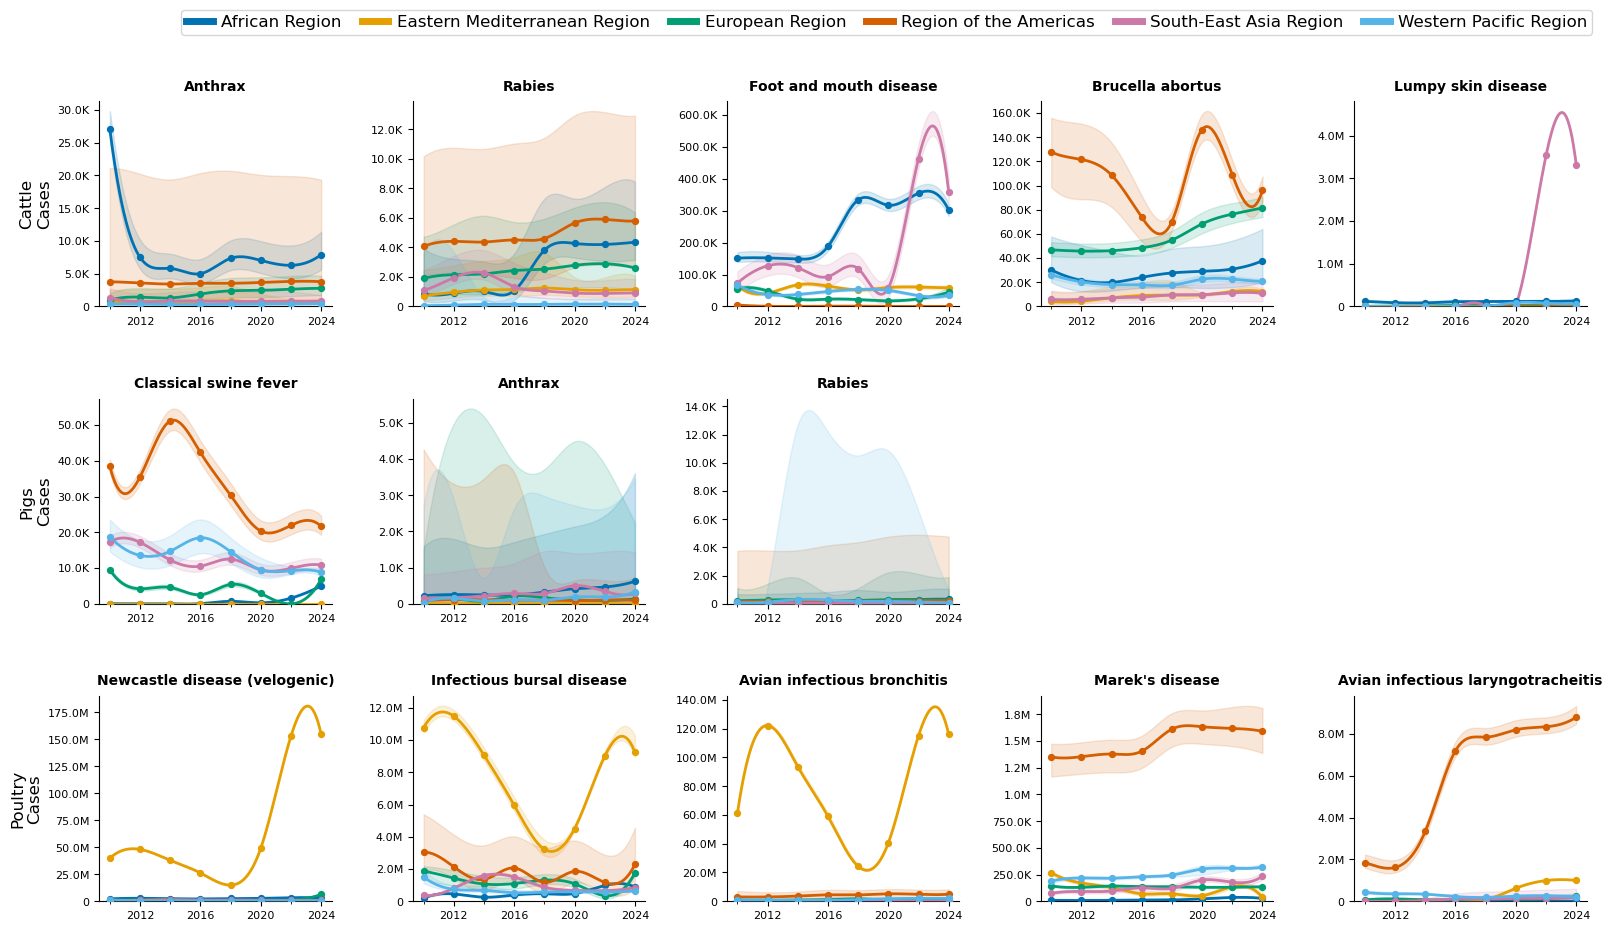

In [30]:
regions = [i.split(' (')[0] for i in list(who_regions.keys())]
regions.sort()

plt.rcParams['font.family'] = 'Arial'
plt.style.use('default')

def easier_format(x, pos):
    if x >= 1e6: return f'{x/1e6:.1f}M'
    if x >= 1e3: return f'{x/1e3:.1f}K'
    return f'{int(x)}'

def make_year_bin(y, bin_size=2, anchor=0):
    y = int(y)
    return y - ((y - anchor) % bin_size)

def bin_label(ystart, bin_size=2):
    yend = int(ystart) + bin_size - 1
    if (ystart // 100) == (yend // 100):
        return f"{ystart}–{str(yend)[-2:]}"
    return f"{ystart}–{yend}"

# aligned 4-year ticks (2012, 2016, 2020,...)
def set_bin_ticks(ax, all_bins, *,
                  mode='aligned',
                  label_every_years=4, anchor_year=2012,
                  target_labels=7,                      # used only if mode='sparse'
                  label_mode='start',                   # 'start' | 'center' | 'range'
                  include_last_label=True,
                  auto_rotate=True, rotate_when_nbins=12, rotate_angle=25):
    """
    Major ticks: chosen subset; Minor ticks: every bin (unlabeled).
    - mode='aligned': label bins where (bin_start - anchor_year) % label_every_years == 0
    - mode='sparse' : ~target_labels labels evenly thinned
    """
    if not all_bins:
        return
    all_bins = list(all_bins)

    if mode == 'aligned':
        label_bins = [b for b in all_bins if ((int(b) - anchor_year) % label_every_years) == 0]
        if not label_bins:
            mode = 'sparse'

    if mode == 'sparse':
        step = max(1, int(np.ceil(len(all_bins) / target_labels)))
        label_bins = all_bins[::step]

    if not include_last_label and label_bins and label_bins[-1] == all_bins[-1]:
        label_bins = label_bins[:-1]

    ax.xaxis.set_major_locator(FixedLocator(label_bins))
    if label_mode == 'start':
        labels = [str(int(b)) for b in label_bins]
    elif label_mode == 'center':
        labels = [str(int(b + 1)) for b in label_bins]  # center year of 2-yr bin
    else:  
        labels = [bin_label(int(b), bin_size=2) for b in label_bins]

    rotate = rotate_angle if (auto_rotate and len(all_bins) > rotate_when_nbins) else 0
    ha = 'right' if rotate else 'center'
    ax.set_xticklabels(labels, fontsize=8, rotation=rotate, ha=ha)

    ax.xaxis.set_minor_locator(FixedLocator(all_bins))
    ax.tick_params(axis='x', which='minor', length=2, labelbottom=False)

# ─── Region palette (Okabe–Ito, 6 distinct hues) ──────────────────────────
OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9"]
region_colors = {reg: OKABE_ITO[i % len(OKABE_ITO)] for i, reg in enumerate(regions)}

LINEWIDTH  = 2.0
BAND_ALPHA = 0.15
MARKER_SZ  = 18

def aggregate_cases_by_disease_and_region(df, diseases, region_list, bin_size=2, min_year=None):
    out = {}
    for disease in diseases:
        out[disease] = {}
        sub_all = df[df['Disease'] == disease].copy()
        if min_year is not None:
            sub_all = sub_all[sub_all['Year'] >= min_year]
        if sub_all.empty:
            continue

        for reg in region_list:
            sub = sub_all[sub_all['Region'] == reg]
            if sub.empty:
                continue

            annual = sub.groupby('Year', as_index=True)[
                ['Cases_estimated_via_incidence',
                 'Cases_estimated_via_incidence_lower',
                 'Cases_estimated_via_incidence_upper']
            ].sum()

            # Average across the years in each bin
            annual = annual.copy()
            annual['YearBin'] = annual.index.map(lambda y: make_year_bin(y, bin_size=bin_size))
            binned = annual.groupby('YearBin', as_index=True).mean()

            out[disease][reg] = {
                'cases': binned['Cases_estimated_via_incidence'].to_dict(),
                'lower': binned['Cases_estimated_via_incidence_lower'].to_dict(),
                'upper': binned['Cases_estimated_via_incidence_upper'].to_dict(),
            }
    return out

simplified_animal_diseases = {
    'Cattle': [
       'Anthrax',
       'Rabies virus (Inf. with)',
       'Foot and mouth disease virus (Inf. with)',
       'Brucella abortus (Inf. with)',
       'Lumpy skin disease virus (Inf. with)'
    ],
    'Pigs': [
       'Classical swine fever virus (Inf. with)',
       'Anthrax',
       'Rabies virus (Inf. with)'
    ],
    'Poultry': [
        'Newcastle disease (velogenic)',
        'Infectious bursal disease (Gumboro disease)',
        'Avian infectious bronchitis',
        "Marek's disease (-2011)",
        'Avian infectious laryngotracheitis'
    ]
}

cattle_data  = aggregate_cases_by_disease_and_region(
    cattle_comprehensive,  simplified_animal_diseases['Cattle'],  regions, bin_size=2, min_year=2010
)
pigs_data    = aggregate_cases_by_disease_and_region(
    swine_comprehensive,   simplified_animal_diseases['Pigs'],    regions, bin_size=2, min_year=2010
)
poultry_data = aggregate_cases_by_disease_and_region(
    poultry_comprehensive, simplified_animal_diseases['Poultry'], regions, bin_size=2, min_year=2010
)
animal_data = {'Cattle': cattle_data, 'Pigs': pigs_data, 'Poultry': poultry_data}

def clean_disease_name(d):
    return (d.replace(" virus (Inf. with)", "")
             .replace(" (poultry) (2006-2021)", "")
             .replace("(Gumboro disease)", "")
             .replace(" (-2011)", "")
             .replace(" (Inf. with)", "")
             .strip())


rows = ['Cattle','Pigs','Poultry']
max_cols = max(len(simplified_animal_diseases[a]) for a in rows)

# Sort diseases within each row by 2024–25 bin (start=2025)
target_year_for_sort = 2025
row_sorted = {}
for animal in rows:
    disease_list = simplified_animal_diseases[animal]
    totals = {}
    for d in disease_list:
        reg_map = animal_data[animal].get(d, {})
        totals[d] = sum(reg_map.get(reg, {}).get('cases', {}).get(target_year_for_sort, 0) for reg in regions)
    row_sorted[animal] = sorted(disease_list, key=lambda dd: totals.get(dd, 0), reverse=True)



fig, axes = plt.subplots(
    nrows=len(rows), ncols=max_cols,
    figsize=(3.5 * max_cols, 10),
    sharex=False, sharey=False
)
plt.subplots_adjust(left=0.05, right=0.90, top=0.88, bottom=0.08, hspace=0.45, wspace=0.35)

encountered_regions = set()

for r, animal in enumerate(rows):
    disease_list = row_sorted[animal]
    data_dict    = animal_data[animal]
    for c in range(max_cols):
        ax = axes[r, c]
        if c >= len(disease_list):
            ax.axis('off')
            continue

        disease = disease_list[c]
        reg_map = data_dict.get(disease, {})
        title = clean_disease_name(disease)
        if title == 'Porcine reproductive and respiratory syndrome':
            title = 'Porcine reproductive\nand respiratory syndrome'
        ax.set_title(title, fontsize=10, fontweight='bold', pad=8)

        if not reg_map:
            ax.axis('off'); continue

        all_bins = sorted({ybin for d in reg_map.values() for ybin in d['cases'].keys()})
        if not all_bins:
            ax.axis('off'); continue

        # Plot each region with consistent color across all subplots
        for reg in regions:
            if reg not in reg_map:
                continue
            encountered_regions.add(reg)

            d = reg_map[reg]
            years = np.array(sorted(d['cases']))
            cases = np.array([d['cases'][y] for y in years])
            lower = np.array([d['lower'][y] for y in years])
            upper = np.array([d['upper'][y] for y in years])

            k = min(3, len(years) - 1)
            if k >= 1:
                xi = np.linspace(years.min(), years.max(), 500)
                yi = make_interp_spline(years, cases, k=k)(xi)
                lo = make_interp_spline(years, lower, k=k)(xi)
                hi = make_interp_spline(years, upper, k=k)(xi)
            else:
                xi, yi, lo, hi = years, cases, lower, upper

            col = region_colors[reg]
            ax.fill_between(xi, lo, hi, color=col, alpha=BAND_ALPHA, zorder=10)
            ax.plot(xi, yi, color=col, linewidth=LINEWIDTH, zorder=11, label=reg)
            ax.scatter(years, cases, color=col, s=MARKER_SZ, zorder=12)

        if c == 0:
            ax.set_ylabel(f"{animal}\nCases", fontsize=12)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=8)
        ax.set_ylim(0)
        ax.yaxis.set_major_formatter(FuncFormatter(easier_format))

        set_bin_ticks(
            ax, all_bins,
            mode='aligned',
            label_every_years=4, anchor_year=2012,
            label_mode='start',
            include_last_label=True,      # ← set True if you want 2025 to show
            auto_rotate=True, rotate_when_nbins=12, rotate_angle=25
        )

# Global top-center legend 
ordered_regions = [reg for reg in regions if reg in encountered_regions]
handles = [Line2D([0], [0], color=region_colors[reg], lw=5) for reg in ordered_regions]

fig.legend(
    handles, ordered_regions,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=min(len(ordered_regions), 6),
    fontsize=12,
    frameon=True,
    borderpad=0.3,
    handlelength=1.6,
    handletextpad=0.5,
    columnspacing=1.2
)

# ─── Save & show ───────────────────────────────────────────────────────────
outdir = "Estimated_Cases_By_region_by_Disease_over_time_2yrbins"
os.makedirs(outdir, exist_ok=True)
fig.savefig(os.path.join(outdir, 'Cases_By_region_by_Disease_2yrbins.png'),
            dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(outdir, 'Cases_By_region_by_Disease_2yrbins.svg'),
            bbox_inches='tight', facecolor='white')
plt.show()


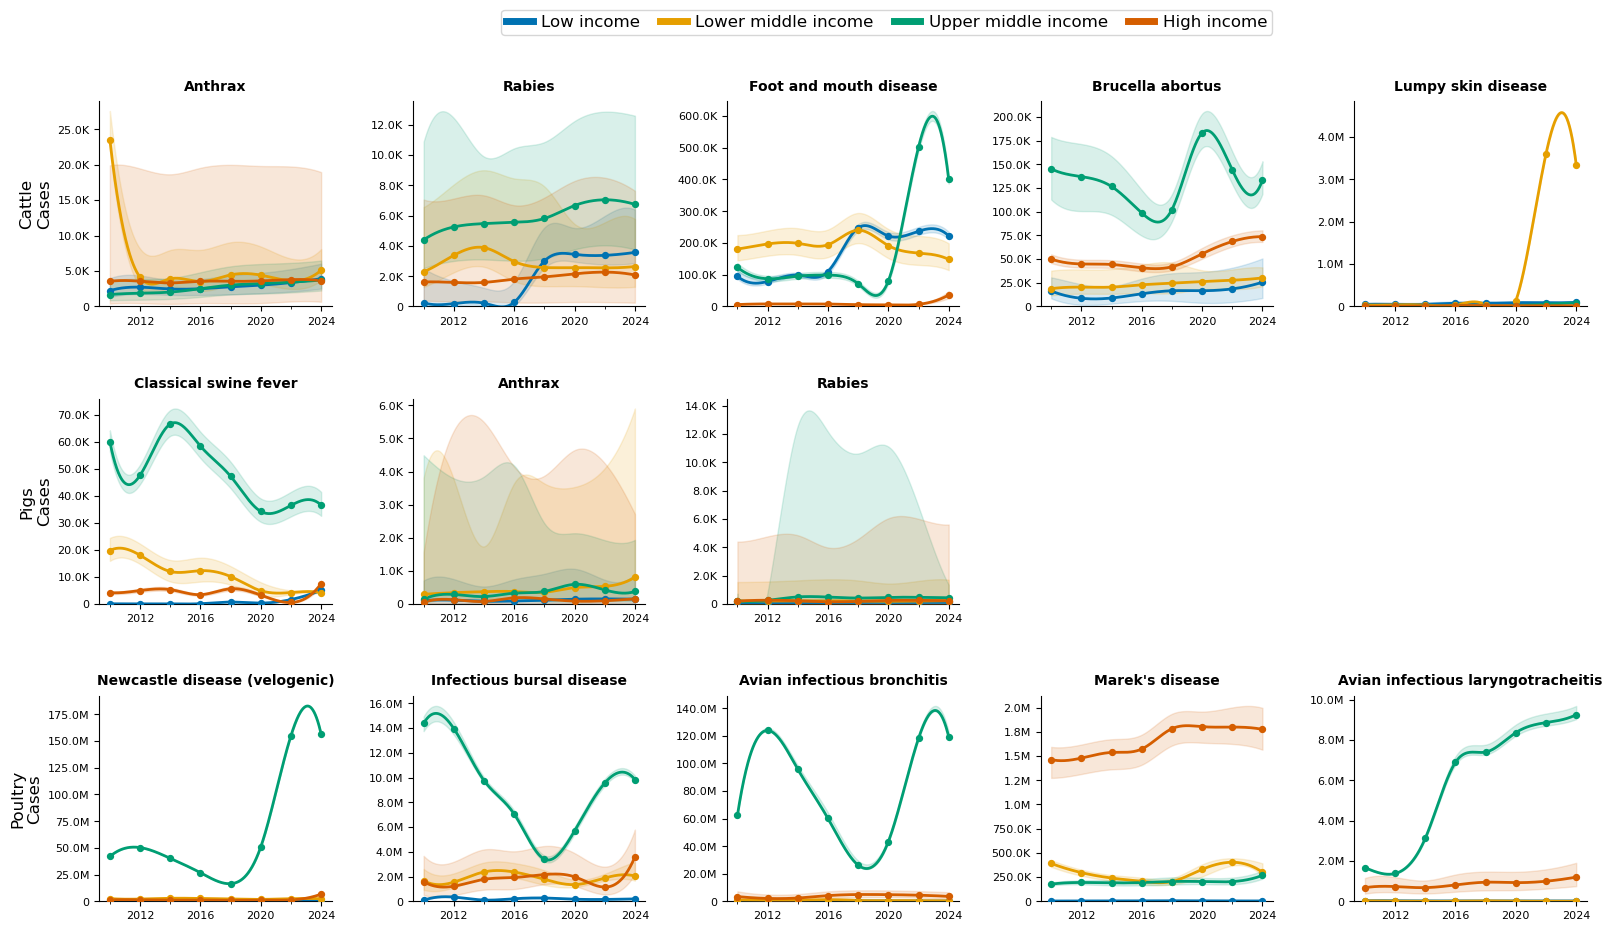

In [31]:
plt.rcParams['font.family'] = 'Arial'
plt.style.use('default')

def easier_format(x, pos):
    if x >= 1e6: return f'{x/1e6:.1f}M'
    if x >= 1e3: return f'{x/1e3:.1f}K'
    return f'{int(x)}'

def make_year_bin(y, bin_size=2, anchor=0):
    y = int(y)
    return y - ((y - anchor) % bin_size)

def bin_label(ystart, bin_size=2):
    yend = int(ystart) + bin_size - 1
    if (ystart // 100) == (yend // 100):
        return f"{ystart}–{str(yend)[-2:]}"
    return f"{ystart}–{yend}"

# Aligned 4-year ticks (2012, 2016, 2020, ...)
def set_bin_ticks(ax, all_bins, *,
                  mode='aligned',
                  label_every_years=4, anchor_year=2012,
                  target_labels=7,                      # used only if mode='sparse'
                  label_mode='start',                   # 'start' | 'center' | 'range'
                  include_last_label=True,
                  auto_rotate=True, rotate_when_nbins=12, rotate_angle=25):
    if not all_bins:
        return
    all_bins = list(all_bins)

    if mode == 'aligned':
        label_bins = [b for b in all_bins if ((int(b) - anchor_year) % label_every_years) == 0]
        if not label_bins:
            mode = 'sparse'
    if mode == 'sparse':
        step = max(1, int(np.ceil(len(all_bins) / target_labels)))
        label_bins = all_bins[::step]

    if not include_last_label and label_bins and label_bins[-1] == all_bins[-1]:
        label_bins = label_bins[:-1]

    ax.xaxis.set_major_locator(FixedLocator(label_bins))
    if label_mode == 'start':
        labels = [str(int(b)) for b in label_bins]
    elif label_mode == 'center':
        labels = [str(int(b + 1)) for b in label_bins]
    else:
        labels = [bin_label(int(b), bin_size=2) for b in label_bins]

    rotate = rotate_angle if (auto_rotate and len(all_bins) > rotate_when_nbins) else 0
    ha = 'right' if rotate else 'center'
    ax.set_xticklabels(labels, fontsize=8, rotation=rotate, ha=ha)

    ax.xaxis.set_minor_locator(FixedLocator(all_bins))
    ax.tick_params(axis='x', which='minor', length=2, labelbottom=False)

income_levels = [
    'Low income',
    'Lower middle income',
    'Upper middle income',
    'High income'
]

# 4 distinct hues 
OKABE_ITO_4 = ["#0072B2", "#E69F00", "#009E73", "#D55E00"]
income_colors = {inc: OKABE_ITO_4[i % len(OKABE_ITO_4)] for i, inc in enumerate(income_levels)}

LINEWIDTH  = 2.0
BAND_ALPHA = 0.15
MARKER_SZ  = 18

def aggregate_cases_by_disease_and_income(df, diseases, income_list, bin_size=2, min_year=None):
    """
    dict[disease][income] -> {'cases': {bin_start: value}, 'lower': {...}, 'upper': {...}}
    Annual totals within year (sum across countries), then mean across the two years in each bin.
    """
    out = {}
    for disease in diseases:
        out[disease] = {}
        sub_all = df[df['Disease'] == disease].copy()
        if min_year is not None:
            sub_all = sub_all[sub_all['Year'] >= min_year]
        if sub_all.empty:
            continue

        for inc in income_list:
            sub = sub_all[sub_all['Income level'] == inc]
            if sub.empty:
                continue

            annual = sub.groupby('Year', as_index=True)[
                ['Cases_estimated_via_incidence',
                 'Cases_estimated_via_incidence_lower',
                 'Cases_estimated_via_incidence_upper']
            ].sum()

            # Average across the years in each bin (annualized)
            annual = annual.copy()
            annual['YearBin'] = annual.index.map(lambda y: make_year_bin(y, bin_size=bin_size))
            binned = annual.groupby('YearBin', as_index=True).mean()

            out[disease][inc] = {
                'cases': binned['Cases_estimated_via_incidence'].to_dict(),
                'lower': binned['Cases_estimated_via_incidence_lower'].to_dict(),
                'upper': binned['Cases_estimated_via_incidence_upper'].to_dict(),
            }
    return out

simplified_animal_diseases = {
    'Cattle': [
       'Anthrax',
       'Rabies virus (Inf. with)',
       'Foot and mouth disease virus (Inf. with)',
       'Brucella abortus (Inf. with)',
       'Lumpy skin disease virus (Inf. with)'
    ],
    'Pigs': [
       'Classical swine fever virus (Inf. with)',
       'Anthrax',
       'Rabies virus (Inf. with)'
    ],
    'Poultry': [
        'Newcastle disease (velogenic)',
        'Infectious bursal disease (Gumboro disease)',
        'Avian infectious bronchitis',
        "Marek's disease (-2011)",
        'Avian infectious laryngotracheitis'
    ]
}

def clean_disease_name(d):
    return (d.replace(" virus (Inf. with)", "")
             .replace(" (poultry) (2006-2021)", "")
             .replace("(Gumboro disease)", "")
             .replace(" (-2011)", "")
             .replace(" (Inf. with)", "")
             .strip())

# Aggregate to 2-year bins
min_year = 2010
cattle_data  = aggregate_cases_by_disease_and_income(
    cattle_comprehensive,  simplified_animal_diseases['Cattle'],  income_levels, bin_size=2, min_year=min_year
)
pigs_data    = aggregate_cases_by_disease_and_income(
    swine_comprehensive,   simplified_animal_diseases['Pigs'],    income_levels, bin_size=2, min_year=min_year
)
poultry_data = aggregate_cases_by_disease_and_income(
    poultry_comprehensive, simplified_animal_diseases['Poultry'], income_levels, bin_size=2, min_year=min_year
)
animal_data = {'Cattle': cattle_data, 'Pigs': pigs_data, 'Poultry': poultry_data}

rows = ['Cattle','Pigs','Poultry']
max_cols = max(len(simplified_animal_diseases[a]) for a in rows)

# Sort diseases within each row by 2024–25 bin (start=2025)
target_year_for_sort = 2025
row_sorted = {}
for animal in rows:
    disease_list = simplified_animal_diseases[animal]
    totals = {}
    for d in disease_list:
        inc_map = animal_data[animal].get(d, {})
        totals[d] = sum(inc_map.get(inc, {}).get('cases', {}).get(target_year_for_sort, 0)
                        for inc in income_levels)
    row_sorted[animal] = sorted(disease_list, key=lambda dd: totals.get(dd, 0), reverse=True)

fig, axes = plt.subplots(
    nrows=len(rows), ncols=max_cols,
    figsize=(3.5 * max_cols, 10),
    sharex=False, sharey=False
)
plt.subplots_adjust(left=0.05, right=0.90, top=0.88, bottom=0.08, hspace=0.45, wspace=0.35)

encountered_incomes = set()

for r, animal in enumerate(rows):
    disease_list = row_sorted[animal]
    data_dict    = animal_data[animal]
    for c in range(max_cols):
        ax = axes[r, c]
        if c >= len(disease_list):
            ax.axis('off')
            continue

        disease = disease_list[c]
        inc_map = data_dict.get(disease, {})
        title = clean_disease_name(disease)
        if title == 'Porcine reproductive and respiratory syndrome':
            title = 'Porcine reproductive\nand respiratory syndrome'
        ax.set_title(title, fontsize=10, fontweight='bold', pad=8)

        if not inc_map:
            ax.axis('off'); continue

        all_bins = sorted({ybin for d in inc_map.values() for ybin in d['cases'].keys()})
        if not all_bins:
            ax.axis('off'); continue

        #Plotting each income level below
        for inc in income_levels:
            if inc not in inc_map:
                continue
            encountered_incomes.add(inc)

            d = inc_map[inc]
            years = np.array(sorted(d['cases']))  # YearBin starts
            cases = np.array([d['cases'][y] for y in years])
            lower = np.array([d['lower'][y] for y in years])
            upper = np.array([d['upper'][y] for y in years])

            k = min(3, len(years) - 1)
            if k >= 1:
                xi = np.linspace(years.min(), years.max(), 500)
                yi = make_interp_spline(years, cases, k=k)(xi)
                lo = make_interp_spline(years, lower, k=k)(xi)
                hi = make_interp_spline(years, upper, k=k)(xi)
            else:
                xi, yi, lo, hi = years, cases, lower, upper

            col = income_colors[inc]
            ax.fill_between(xi, lo, hi, color=col, alpha=BAND_ALPHA, zorder=10)
            ax.plot(xi, yi, color=col, linewidth=LINEWIDTH, zorder=11, label=inc)
            ax.scatter(years, cases, color=col, s=MARKER_SZ, zorder=12)

        if c == 0:
            
            ax.set_ylabel(f"{animal}\nCases", fontsize=12)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=8)
        ax.set_ylim(0)
        ax.yaxis.set_major_formatter(FuncFormatter(easier_format))

        set_bin_ticks(
            ax, all_bins,
            mode='aligned',
            label_every_years=4, anchor_year=2012,
            label_mode='start',
            include_last_label=True,     # set False to hide the final rightmost label
            auto_rotate=True, rotate_when_nbins=12, rotate_angle=25
        )

# Global top-center legend
ordered_incomes = [inc for inc in income_levels if inc in encountered_incomes]
handles = [Line2D([0], [0], color=income_colors[inc], lw=5) for inc in ordered_incomes]

fig.legend(
    handles, ordered_incomes,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=min(len(ordered_incomes), 4),
    fontsize=12,
    frameon=True,
    borderpad=0.3,
    handlelength=1.6,
    handletextpad=0.5,
    columnspacing=1.2
)

outdir = "Estimated_Cases_By_income_by_Disease_2yrbins"
os.makedirs(outdir, exist_ok=True)
fig.savefig(os.path.join(outdir, 'Cases_By_income_by_Disease_2yrbins.png'),
            dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(outdir, 'Cases_By_income_by_Disease_2yrbins.svg'),
            bbox_inches='tight', facecolor='white')
plt.show()


# Saving order of plotted diseases for consistency in following graphics
order_outdir = "Estimated_Cases_By_region_by_Disease_over_time_2yrbins"
order_path = os.path.join(order_outdir, "disease_order_by_cases_2025.json")
row_sorted_json = {k: list(v) for k, v in row_sorted.items()}
with open(order_path, "w", encoding="utf-8") as f:
    json.dump(row_sorted_json, f, ensure_ascii=False, indent=2)


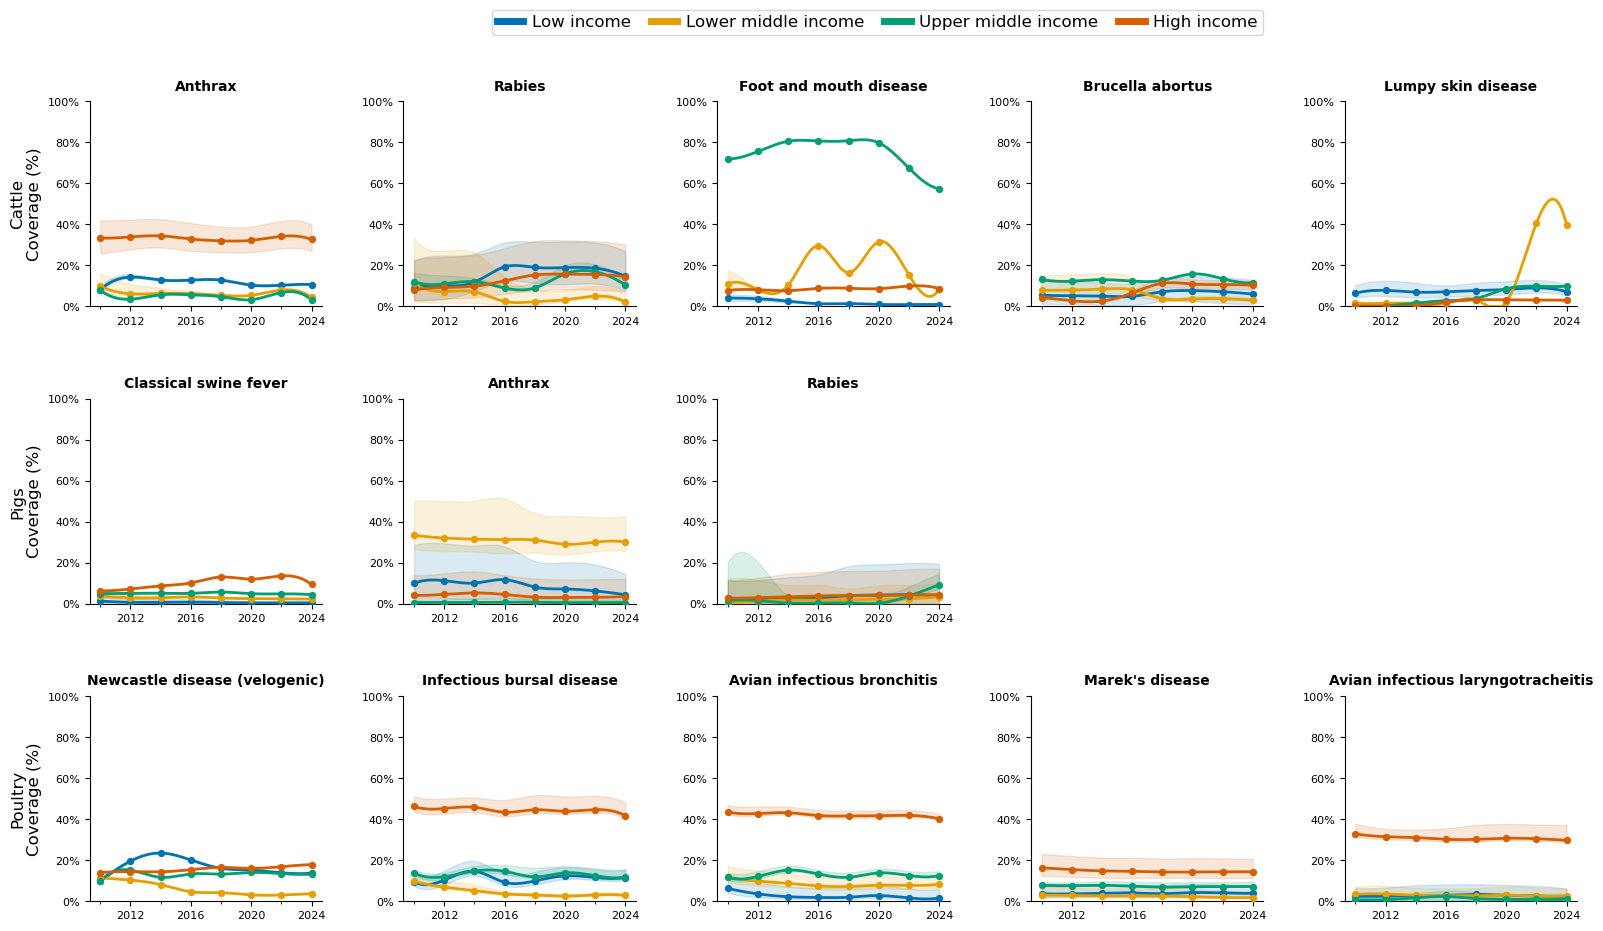

In [32]:
plt.rcParams['font.family'] = 'Arial'
plt.style.use('default')

def make_year_bin(y, bin_size=2, anchor=0):
    y = int(y)
    return y - ((y - anchor) % bin_size)

def bin_label(ystart, bin_size=2):
    yend = int(ystart) + bin_size - 1
    if (ystart // 100) == (yend // 100):
        return f"{ystart}–{str(yend)[-2:]}"
    return f"{ystart}–{yend}"

def set_bin_ticks(ax, all_bins, *,
                  mode='aligned',
                  label_every_years=4, anchor_year=2012,
                  target_labels=7,                      # used only if mode='sparse'
                  label_mode='start',                   # 'start' | 'center' | 'range'
                  include_last_label=True,
                  auto_rotate=True, rotate_when_nbins=12, rotate_angle=25):
    """Major ticks: chosen subset; Minor: every bin (unlabeled)."""
    if not all_bins:
        return
    all_bins = list(all_bins)

    if mode == 'aligned':
        label_bins = [b for b in all_bins if ((int(b) - anchor_year) % label_every_years) == 0]
        if not label_bins:
            mode = 'sparse'
    if mode == 'sparse':
        step = max(1, int(np.ceil(len(all_bins) / target_labels)))
        label_bins = all_bins[::step]

    if not include_last_label and label_bins and label_bins[-1] == all_bins[-1]:
        label_bins = label_bins[:-1]

    ax.xaxis.set_major_locator(FixedLocator(label_bins))
    if label_mode == 'start':
        labels = [str(int(b)) for b in label_bins]
    elif label_mode == 'center':
        labels = [str(int(b + 1)) for b in label_bins]
    else:
        labels = [bin_label(int(b), bin_size=2) for b in label_bins]

    rotate = rotate_angle if (auto_rotate and len(all_bins) > rotate_when_nbins) else 0
    ha = 'right' if rotate else 'center'
    ax.set_xticklabels(labels, fontsize=8, rotation=rotate, ha=ha)

    ax.xaxis.set_minor_locator(FixedLocator(all_bins))
    ax.tick_params(axis='x', which='minor', length=2, labelbottom=False)

income_levels = [
    'Low income',
    'Lower middle income',
    'Upper middle income',
    'High income'
]
OKABE_ITO_4 = ["#0072B2", "#E69F00", "#009E73", "#D55E00"]  # blue, orange, green, red
income_colors = {inc: OKABE_ITO_4[i % len(OKABE_ITO_4)] for i, inc in enumerate(income_levels)}

LINEWIDTH  = 2.0
BAND_ALPHA = 0.15
MARKER_SZ  = 18

def aggregate_cases_by_disease_and_income(df, diseases, income_list, bin_size=2, min_year=None):
    """
    Returns dict[disease][income] with per-bin coverage and bounds:
      {
        'cov':   {bin_start: coverage 0..1},
        'lower': {bin_start: lower},
        'upper': {bin_start: upper},
        'num':   {bin_start: Σ vacc in bin},   # optional: for sorting/weights
        'den':   {bin_start: Σ pop  in bin}
      }

    Method:
      1) For each (disease, income): for each Year, SUM across countries:
         vac, vacL, vacU, pop.
      2) Map Year → YearBin; within each bin, SUM across the years (ratio-of-sums):
         cov_bin = (Σ vac) / (Σ pop), etc.  (Population-weighted.)
    """
    out = {}
    has_atrisk = ('Estimated (Scaled) Cases' in df.columns)

    for disease in diseases:
        out[disease] = {}

        if has_atrisk and ('castle' not in disease.lower()):
            sub_all = df[(df['Disease'] == disease) &
                         df['Number of Vaccinated Estimate'].notna() &
                         df['latest pop'].notna() &
                         df['Estimated (Scaled) Cases'].notna()]
        else:
            sub_all = df[(df['Disease'] == disease) &
                         df['Number of Vaccinated Estimate'].notna() &
                         df['latest pop'].notna()]

        if min_year is not None:
            sub_all = sub_all[sub_all['Year'] >= min_year]
        if sub_all.empty:
            continue

        for inc in income_list:
            sub = sub_all[sub_all['Income level'] == inc]
            if sub.empty:
                continue

            # Annual totals (sum countries per year)
            g = sub.groupby('Year', as_index=True)[
                ['Number of Vaccinated Estimate',
                 'Number of Vaccinated Lower',
                 'Number of Vaccinated Upper',
                 'latest pop']
            ].sum().rename(columns={
                'Number of Vaccinated Estimate': 'vac',
                'Number of Vaccinated Lower':   'vacL',
                'Number of Vaccinated Upper':   'vacU',
                'latest pop':                   'pop'
            })

            if g.empty:
                continue

            # Bin by year, then ratio-of-sums within each bin
            g = g.copy()
            g['YearBin'] = g.index.map(lambda y: make_year_bin(y, bin_size=bin_size))
            bsum = g.groupby('YearBin', as_index=True)[['vac', 'vacL', 'vacU', 'pop']].sum()

            den = bsum['pop'].replace(0, np.nan)
            cov = (bsum['vac']  / den).astype(float)
            lo  = (bsum['vacL'] / den).astype(float)
            hi  = (bsum['vacU'] / den).astype(float)

            out[disease][inc] = {
                'cov':   cov.to_dict(),
                'lower': lo.to_dict(),
                'upper': hi.to_dict(),
                'num':   bsum['vac'].to_dict(),
                'den':   bsum['pop'].to_dict()
            }
    return out

simplified_animal_diseases = {
    'Cattle': [
       'Anthrax',
       'Rabies virus (Inf. with)',
       'Foot and mouth disease virus (Inf. with)',
       'Brucella abortus (Inf. with)',
       'Lumpy skin disease virus (Inf. with)'
    ],
    'Pigs': [
       'Classical swine fever virus (Inf. with)',
       'Anthrax',
       'Rabies virus (Inf. with)'
    ],
    'Poultry': [
        'Newcastle disease (velogenic)',
        'Infectious bursal disease (Gumboro disease)',
        'Avian infectious bronchitis',
        "Marek's disease (-2011)",
        'Avian infectious laryngotracheitis'
    ]
}

def clean_disease_name(d):
    return (d.replace(" virus (Inf. with)", "")
             .replace(" (poultry) (2006-2021)", "")
             .replace("(Gumboro disease)", "")
             .replace(" (-2011)", "")
             .replace(" (Inf. with)", "")
             .strip())

# Aggregate to 2-year bins
min_year = 2010
cattle_data  = aggregate_cases_by_disease_and_income(
    cattle_comprehensive,  simplified_animal_diseases['Cattle'],  income_levels, bin_size=2, min_year=min_year
)
pigs_data    = aggregate_cases_by_disease_and_income(
    swine_comprehensive,   simplified_animal_diseases['Pigs'],    income_levels, bin_size=2, min_year=min_year
)
poultry_data = aggregate_cases_by_disease_and_income(
    poultry_comprehensive, simplified_animal_diseases['Poultry'], income_levels, bin_size=2, min_year=min_year
)
animal_data = {'Cattle': cattle_data, 'Pigs': pigs_data, 'Poultry': poultry_data}


order_path = os.path.join(order_outdir, "disease_order_by_cases_2025.json")

if os.path.exists(order_path):
    with open(order_path, "r", encoding="utf-8") as f:
        order_from_cases = json.load(f)
else:
    order_from_cases = {}

rows = ['Cattle','Pigs','Poultry']
row_sorted = {}

for animal in rows:
    if animal in order_from_cases:
        desired_order = [d for d in order_from_cases[animal] if d in simplified_animal_diseases[animal]]

        remainder = [d for d in simplified_animal_diseases[animal] if d not in desired_order]
        row_sorted[animal] = desired_order + remainder
    else:
        disease_list = simplified_animal_diseases[animal]
        scores = {}
        target_bin = 2025
        for d in disease_list:
            reg_map = animal_data[animal].get(d, {})
            num = sum(reg_map.get(reg, {}).get('num', {}).get(target_bin, 0.0) for reg in regions)
            den = sum(reg_map.get(reg, {}).get('den', {}).get(target_bin, 0.0) for reg in regions)
            scores[d] = (num / den) if den > 0 else -np.inf
        row_sorted[animal] = sorted(disease_list, key=lambda dd: scores.get(dd, -np.inf), reverse=True)


fig, axes = plt.subplots(
    nrows=len(rows), ncols=max_cols,
    figsize=(3.5 * max_cols, 10),
    sharex=False, sharey=False
)
plt.subplots_adjust(left=0.05, right=0.90, top=0.88, bottom=0.08, hspace=0.45, wspace=0.35)

encountered_incomes = set()

for r, animal in enumerate(rows):
    disease_list = row_sorted[animal]
    data_dict    = animal_data[animal]
    for c in range(max_cols):
        ax = axes[r, c]
        if c >= len(disease_list):
            ax.axis('off'); continue

        disease = disease_list[c]
        inc_map = data_dict.get(disease, {})
        title = clean_disease_name(disease)
        if title == 'Porcine reproductive and respiratory syndrome':
            title = 'Porcine reproductive\nand respiratory syndrome'
        ax.set_title(title, fontsize=10, fontweight='bold', pad=8)

        if not inc_map:
            ax.axis('off'); continue

        all_bins = sorted({b for v in inc_map.values() for b in v['cov'].keys()})
        if not all_bins:
            ax.axis('off'); continue

        for inc in income_levels:
            if inc not in inc_map:
                continue
            encountered_incomes.add(inc)
            d = inc_map[inc]

            years = np.array(sorted(d['cov']))  # YearBin starts
            cov   = np.array([d['cov'][y]   for y in years], float)
            lo    = np.array([d['lower'][y] for y in years], float)
            hi    = np.array([d['upper'][y] for y in years], float)

            k = min(3, len(years) - 1)
            if k >= 1:
                xi = np.linspace(years.min(), years.max(), 500)
                yi = make_interp_spline(years, cov, k=k)(xi)
                yl = make_interp_spline(years, lo,  k=k)(xi)
                yh = make_interp_spline(years, hi,  k=k)(xi)
            else:
                xi, yi, yl, yh = years, cov, lo, hi

            yi = np.clip(yi, 0, 1)
            yl = np.clip(yl, 0, 1)
            yh = np.clip(yh, 0, 1)

            col = income_colors[inc]
            ax.fill_between(xi, yl, yh, color=col, alpha=BAND_ALPHA, zorder=10)
            ax.plot(xi, yi, color=col, linewidth=LINEWIDTH, zorder=11, label=inc)
            ax.scatter(years, cov, color=col, s=MARKER_SZ, zorder=12)

        if c == 0:
            ax.set_ylabel(f"{animal}\nCoverage (%)", fontsize=12)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=8)

        # Fixed 0–100% across all panels
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))

        # Clean, aligned x-ticks (2012, 2016, 2020,...)
        set_bin_ticks(
            ax, all_bins,
            mode='aligned',
            label_every_years=4, anchor_year=2012,
            label_mode='start',
            include_last_label=True,   # set False to hide the last label
            auto_rotate=True, rotate_when_nbins=12, rotate_angle=25
        )

# Global top-center legend
ordered_incomes = [inc for inc in income_levels if inc in encountered_incomes]
handles = [Line2D([0], [0], color=income_colors[inc], lw=5) for inc in ordered_incomes]

fig.legend(
    handles, ordered_incomes,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=min(len(ordered_incomes), 4),
    fontsize=12,
    frameon=True,
    borderpad=0.3,
    handlelength=1.6,
    handletextpad=0.5,
    columnspacing=1.2
)

outdir = "Estimated_Coverage_By_income_by_Disease_2yrbins"
os.makedirs(outdir, exist_ok=True)
fig.savefig(os.path.join(outdir, 'Coverage_By_income_by_Disease_2yrbins.png'),
            dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(outdir, 'Coverage_By_income_by_Disease_2yrbins.svg'),
            bbox_inches='tight', facecolor='white')
plt.show()


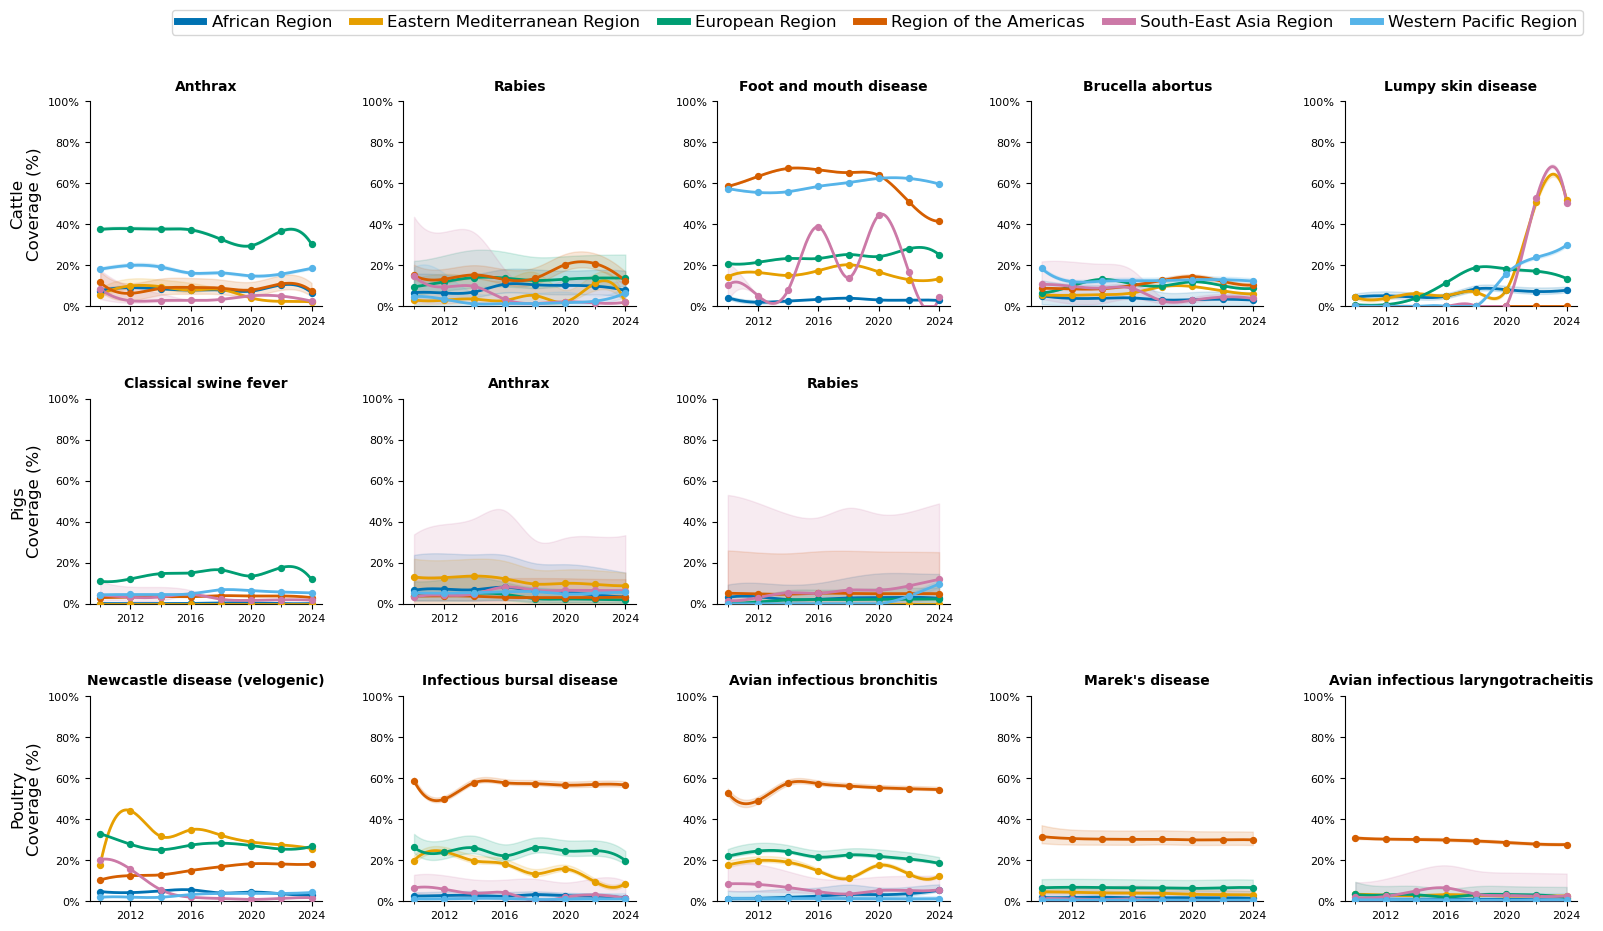

In [33]:
regions = [i.split(' (')[0] for i in list(who_regions.keys())]
regions.sort()


plt.rcParams['font.family'] = 'Arial'
plt.style.use('default')

def make_year_bin(y, bin_size=2, anchor=0):
    y = int(y)
    return y - ((y - anchor) % bin_size)

def bin_label(ystart, bin_size=2):
    yend = int(ystart) + bin_size - 1
    if (ystart // 100) == (yend // 100):
        return f"{ystart}–{str(yend)[-2:]}"
    return f"{ystart}–{yend}"

def set_bin_ticks(ax, all_bins, *,
                  mode='aligned',
                  label_every_years=4, anchor_year=2012,
                  target_labels=7,                     
                  label_mode='start',                  
                  include_last_label=True,
                  auto_rotate=True, rotate_when_nbins=12, rotate_angle=25):
    """Major ticks: chosen subset; Minor: every bin (unlabeled)."""
    if not all_bins:
        return
    all_bins = list(all_bins)

    if mode == 'aligned':
        label_bins = [b for b in all_bins if ((int(b) - anchor_year) % label_every_years) == 0]
        if not label_bins:
            mode = 'sparse'
    if mode == 'sparse':
        step = max(1, int(np.ceil(len(all_bins) / target_labels)))
        label_bins = all_bins[::step]

    if not include_last_label and label_bins and label_bins[-1] == all_bins[-1]:
        label_bins = label_bins[:-1]

    ax.xaxis.set_major_locator(FixedLocator(label_bins))
    if label_mode == 'start':
        labels = [str(int(b)) for b in label_bins]
    elif label_mode == 'center':
        labels = [str(int(b + 1)) for b in label_bins]
    else:
        labels = [bin_label(int(b), bin_size=2) for b in label_bins]

    rotate = rotate_angle if (auto_rotate and len(all_bins) > rotate_when_nbins) else 0
    ha = 'right' if rotate else 'center'
    ax.set_xticklabels(labels, fontsize=8, rotation=rotate, ha=ha)

    ax.xaxis.set_minor_locator(FixedLocator(all_bins))
    ax.tick_params(axis='x', which='minor', length=2, labelbottom=False)

OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9"]
region_colors = {reg: OKABE_ITO[i % len(OKABE_ITO)] for i, reg in enumerate(regions)}

LINEWIDTH  = 2.0
BAND_ALPHA = 0.15
MARKER_SZ  = 18

def aggregate_coverage_by_disease_and_region(df, diseases, region_list, bin_size=2, min_year=None):
    """
    dict[disease][region] -> {
        'cov':   {bin_start: coverage 0..1},
        'lower': {bin_start: lower},
        'upper': {bin_start: upper},
        'num':   {bin_start: Σ vacc in bin},
        'den':   {bin_start: Σ pop  in bin}
    }
    Coverage per bin uses ratio-of-sums across the years:
        cov_bin = (Σ vacc) / (Σ pop)
    """
    out = {}
    has_atrisk = ('Estimated (Scaled) Cases' in df.columns)

    for disease in diseases:
        out[disease] = {}

        if has_atrisk and ('castle' not in disease.lower()):
            sub_all = df[(df['Disease'] == disease) &
                         df['Number of Vaccinated Estimate'].notna() &
                         df['latest pop'].notna() &
                         df['Estimated (Scaled) Cases'].notna()]
        else:
            sub_all = df[(df['Disease'] == disease) &
                         df['Number of Vaccinated Estimate'].notna() &
                         df['latest pop'].notna()]

        if min_year is not None:
            sub_all = sub_all[sub_all['Year'] >= min_year]
        if sub_all.empty:
            continue

        for reg in region_list:
            sub = sub_all[sub_all['Region'] == reg]
            if sub.empty:
                continue

            # Annual totals
            g = sub.groupby('Year', as_index=True)[
                ['Number of Vaccinated Estimate',
                 'Number of Vaccinated Lower',
                 'Number of Vaccinated Upper',
                 'latest pop']
            ].sum().rename(columns={
                'Number of Vaccinated Estimate': 'vac',
                'Number of Vaccinated Lower':   'vacL',
                'Number of Vaccinated Upper':   'vacU',
                'latest pop':                   'pop'
            })
            if g.empty:
                continue

            #Bin by year, then ratio-of-sums within each bin
            g = g.copy()
            g['YearBin'] = g.index.map(lambda y: make_year_bin(y, bin_size=bin_size))
            bsum = g.groupby('YearBin', as_index=True)[['vac','vacL','vacU','pop']].sum()

            den = bsum['pop'].replace(0, np.nan)
            cov = (bsum['vac']  / den).astype(float)
            lo  = (bsum['vacL'] / den).astype(float)
            hi  = (bsum['vacU'] / den).astype(float)

            out[disease][reg] = {
                'cov':   cov.to_dict(),
                'lower': lo.to_dict(),
                'upper': hi.to_dict(),
                'num':   bsum['vac'].to_dict(),
                'den':   bsum['pop'].to_dict()
            }
    return out

simplified_animal_diseases = {
    'Cattle': [
       'Anthrax',
       'Rabies virus (Inf. with)',
       'Foot and mouth disease virus (Inf. with)',
       'Brucella abortus (Inf. with)',
       'Lumpy skin disease virus (Inf. with)'
    ],
    'Pigs': [
       'Classical swine fever virus (Inf. with)',
       'Anthrax',
       'Rabies virus (Inf. with)'
    ],
    'Poultry': [
        'Newcastle disease (velogenic)',
        'Infectious bursal disease (Gumboro disease)',
        'Avian infectious bronchitis',
        "Marek's disease (-2011)",
        'Avian infectious laryngotracheitis'
    ]
}

def clean_disease_name(d):
    return (d.replace(" virus (Inf. with)", "")
             .replace(" (poultry) (2006-2021)", "")
             .replace("(Gumboro disease)", "")
             .replace(" (-2011)", "")
             .replace(" (Inf. with)", "")
             .strip())

# Aggregate to 2-year bins 
min_year = 2010
cattle_data  = aggregate_coverage_by_disease_and_region(
    cattle_comprehensive,  simplified_animal_diseases['Cattle'],  regions, bin_size=2, min_year=min_year
)
pigs_data    = aggregate_coverage_by_disease_and_region(
    swine_comprehensive,   simplified_animal_diseases['Pigs'],    regions, bin_size=2, min_year=min_year
)
poultry_data = aggregate_coverage_by_disease_and_region(
    poultry_comprehensive, simplified_animal_diseases['Poultry'], regions, bin_size=2, min_year=min_year
)
animal_data = {'Cattle': cattle_data, 'Pigs': pigs_data, 'Poultry': poultry_data}

#Sorting plots by disease based on total cases plotted earlier
order_path = os.path.join(
    "Estimated_Cases_By_region_by_Disease_over_time_2yrbins",
    "disease_order_by_cases_2025.json"
)

if os.path.exists(order_path):
    with open(order_path, "r", encoding="utf-8") as f:
        order_from_cases = json.load(f)
else:
    order_from_cases = {}

rows = ['Cattle','Pigs','Poultry']
row_sorted = {}

for animal in rows:
    # Sort from incidence-defined order
    if animal in order_from_cases:
        desired_order = [d for d in order_from_cases[animal] if d in simplified_animal_diseases[animal]]

        remainder = [d for d in simplified_animal_diseases[animal] if d not in desired_order]
        row_sorted[animal] = desired_order + remainder
    else:
        disease_list = simplified_animal_diseases[animal]
        scores = {}
        target_bin = 2025
        for d in disease_list:
            reg_map = animal_data[animal].get(d, {})
            num = sum(reg_map.get(reg, {}).get('num', {}).get(target_bin, 0.0) for reg in regions)
            den = sum(reg_map.get(reg, {}).get('den', {}).get(target_bin, 0.0) for reg in regions)
            scores[d] = (num / den) if den > 0 else -np.inf
        row_sorted[animal] = sorted(disease_list, key=lambda dd: scores.get(dd, -np.inf), reverse=True)



fig, axes = plt.subplots(
    nrows=len(rows), ncols=max_cols,
    figsize=(3.5 * max_cols, 10),
    sharex=False, sharey=False
)
plt.subplots_adjust(left=0.05, right=0.90, top=0.88, bottom=0.08, hspace=0.45, wspace=0.35)

encountered_regions = set()

for r, animal in enumerate(rows):
    disease_list = row_sorted[animal]
    data_dict    = animal_data[animal]
    for c in range(max_cols):
        ax = axes[r, c]
        if c >= len(disease_list):
            ax.axis('off'); continue

        disease = disease_list[c]
        reg_map = data_dict.get(disease, {})
        title = clean_disease_name(disease)
        if title == 'Porcine reproductive and respiratory syndrome':
            title = 'Porcine reproductive\nand respiratory syndrome'
        ax.set_title(title, fontsize=10, fontweight='bold', pad=8)

        if not reg_map:
            ax.axis('off'); continue

        all_bins = sorted({b for v in reg_map.values() for b in v['cov'].keys()})
        if not all_bins:
            ax.axis('off'); continue

        for reg in regions:
            if reg not in reg_map:
                continue
            encountered_regions.add(reg)
            d = reg_map[reg]

            years = np.array(sorted(d['cov']))      # YearBin starts
            cov   = np.array([d['cov'][y]   for y in years], float)
            lo    = np.array([d['lower'][y] for y in years], float)
            hi    = np.array([d['upper'][y] for y in years], float)

            k = min(3, len(years) - 1)
            if k >= 1:
                xi = np.linspace(years.min(), years.max(), 500)
                yi = make_interp_spline(years, cov, k=k)(xi)
                yl = make_interp_spline(years, lo,  k=k)(xi)
                yh = make_interp_spline(years, hi,  k=k)(xi)
            else:
                xi, yi, yl, yh = years, cov, lo, hi

            yi = np.clip(yi, 0, 1)
            yl = np.clip(yl, 0, 1)
            yh = np.clip(yh, 0, 1)

            col = region_colors[reg]
            ax.fill_between(xi, yl, yh, color=col, alpha=BAND_ALPHA, zorder=10)
            ax.plot(xi, yi, color=col, linewidth=LINEWIDTH, zorder=11, label=reg)
            ax.scatter(years, cov, color=col, s=MARKER_SZ, zorder=12)

        if c == 0:
            ax.set_ylabel(f"{animal}\nCoverage (%)", fontsize=12)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=8)

        # Fixed 0–100% across all panels
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))

        # Clean, aligned x-ticks (2012, 2016, 2020,...)
        set_bin_ticks(
            ax, all_bins,
            mode='aligned',
            label_every_years=4, anchor_year=2012,
            label_mode='start',
            include_last_label=True,   
            auto_rotate=True, rotate_when_nbins=12, rotate_angle=25
        )

# Global top-center legend
ordered_regions = [reg for reg in regions if reg in encountered_regions]
handles = [Line2D([0], [0], color=region_colors[reg], lw=5) for reg in ordered_regions]

fig.legend(
    handles, ordered_regions,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=min(len(ordered_regions), 6),
    fontsize=12,
    frameon=True,
    borderpad=0.3,
    handlelength=1.6,
    handletextpad=0.5,
    columnspacing=1.2
)
outdir = "Estimated_Coverage_By_region_by_Disease_2yrbins"
os.makedirs(outdir, exist_ok=True)
fig.savefig(os.path.join(outdir, 'Coverage_By_region_by_Disease_2yrbins.png'),
            dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(outdir, 'Coverage_By_region_by_Disease_2yrbins.svg'),
            bbox_inches='tight', facecolor='white')
plt.show()
